In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [36]:
df_raw = pd.read_csv('0b05b2dd-4772-4fd5-b98a-8de02d94cd75_Data.csv', sep = ',')
df = df_raw.drop(columns = ['Country Name', 'Series Code'])
df = df.dropna(axis = 0)

id_vars = ["Country Code", "Series Name"]
value_vars = [c for c in df.columns if "[" in c and "YR" in c] 

df_long = df.melt(
    id_vars = id_vars,          # stay as identifier columns
    value_vars = value_vars,    # all the year columns
    var_name = "Year_raw",      # column that will hold things like "2005 [YR2005]"
    value_name = "Value"        # numeric data from those cells
)

df_long['Year'] = df_long['Year_raw'].str[0:4].astype(int)
df_long = df_long.drop(columns = 'Year_raw')

df_pivot = df_long.pivot(index = ['Country Code', 'Year'], columns = 'Series Name', values = 'Value')

df_pivot.columns.name = None

df_pivot['year_mask'] = (df_pivot.index.get_level_values('Year') > 2018) & (df_pivot.index.get_level_values('Year') < 2024)
df = df_pivot[df_pivot['year_mask']]

df = df.replace('..', None)

flag = df.isna().sum()/df.shape[0] < 0.3
df = df.loc[:, flag]

col_map = {
    "Access to clean fuels and technologies for cooking (% of population)": "clean_cooking",
    "Access to electricity (% of population)": "elec_total",
    "Access to electricity, rural (% of rural population)": "elec_rural",
    "Access to electricity, urban (% of urban population)": "elec_urban",
    "Current health expenditure (% of GDP)": "health_exp_gdp",
    "Current health expenditure per capita (current US$)": "health_exp_pc",
    "GDP per capita (current US$)": "gdp_pc",
    "GNI per capita, Atlas method (current US$)": "gni_pc_atlas",
    "Individuals using the Internet (% of population)": "internet_use",
    "Life expectancy at birth, total (years)": "life_exp",
    "People using at least basic drinking water services (% of population)": "basic_water",
    "People using at least basic drinking water services, rural (% of rural population)": "basic_water_rural",
    "People using at least basic drinking water services, urban (% of urban population)": "basic_water_urban",
    "Population density (people per sq. km of land area)": "pop_density",
    "Population, female": "pop_female",
    "Population, male": "pop_male",
    "Rural population (% of total population)": "rural_share",
    "School enrollment, primary (% gross)": "enroll_primary",
    "School enrollment, secondary (% gross)": "enroll_secondary",
    "Urban population (% of total population)": "urban_share",
    "Lifetime risk of maternal death (%)": "maternal_risk",
    "Mortality rate, infant, female (per 1,000 live births)": "infant_mort_f",
    "Mortality rate, infant, male (per 1,000 live births)": "infant_mort_m"
}

df.rename(col_map, axis = 1, inplace = True)


region_list = ["AFE", "AFW", "CSS", "EAS", "EAP", "EAR", "ECS", "ECA", "ECB",
    "EMU", "EUU", "FCS", "HIC", "HPC", "IBD", "IBT", "IDA", "IDX",
    "LAC", "LCN", "LCE", "LDC", "LIC", "LMC", "LMY", "MIC", "NOC",
    "OED", "OSS", "PSS", "PDI", "PRE", "SAS", "TSA", "SSA", "SSF",
    "SSX", "UMC", "WLD", "ARB", "MNA", "TMN", "MXX",
    "SAR", "MEA", "PST", "TEA", "LTE", "NAC", "IDB",
    "CEB"]
df = df[~df.index.get_level_values("Country Code").isin(region_list)]

df = df.map(lambda x: round(float(x), 2), na_action = "ignore")

df['usable_year'] = df.isna().mean(axis = 1)
df['flag'] = df['usable_year'] < 0.2

country_mask = df.groupby("Country Code")['flag'].mean() > 0.7
df["analisable"] = df.index.get_level_values("Country Code").map(country_mask)
df_good_prefillna = df[df['analisable']]
df_bad = df[~df['analisable']]

df_good_prefillna = df_good_prefillna.drop(columns = ['flag', 'analisable', 'year_mask', 'usable_year'])

df_good = df_good_prefillna.fillna(df_good_prefillna.groupby("Country Code").median())

small_na_cols = ['clean_cooking', 'elec_rural', 'internet_use', 'gni_pc_atlas', 'basic_water']
df_good[small_na_cols] = df_good[small_na_cols].fillna(df_good[small_na_cols].median())

big_na_cols = ['basic_water_rural', 'basic_water_urban', 'enroll_primary', 'enroll_secondary'] 
df_good = df_good.drop(columns = big_na_cols)


In [37]:
loggable = ['health_exp_pc', 'gdp_pc', 'gni_pc_atlas', 'maternal_risk', 'pop_density', 'pop_female', 
'pop_male']
df_good[loggable] = np.log1p(df_good[loggable])

In [38]:
df_good = df_good.groupby('Country Code').mean()
country_index = df_good.index

In [39]:
df_good = df_good.reset_index().drop(columns = 'Country Code')

In [40]:
df_good.isna().sum()

clean_cooking     0
elec_total        0
elec_rural        0
elec_urban        0
health_exp_gdp    0
health_exp_pc     0
gdp_pc            0
gni_pc_atlas      0
internet_use      0
life_exp          0
maternal_risk     0
infant_mort_f     0
infant_mort_m     0
basic_water       0
pop_density       0
pop_female        0
pop_male          0
rural_share       0
urban_share       0
dtype: int64

In [41]:
scaler = StandardScaler()
data = scaler.fit_transform(df_good)

In [42]:

aics = []
sils = []
for k in np.arange(2, 10):

    gmm = GaussianMixture(k, random_state = 42)
    gmm.fit(data)
    aics.append(gmm.aic(data))
    prediction = gmm.predict(data)
    sils.append(silhouette_score(data, prediction))


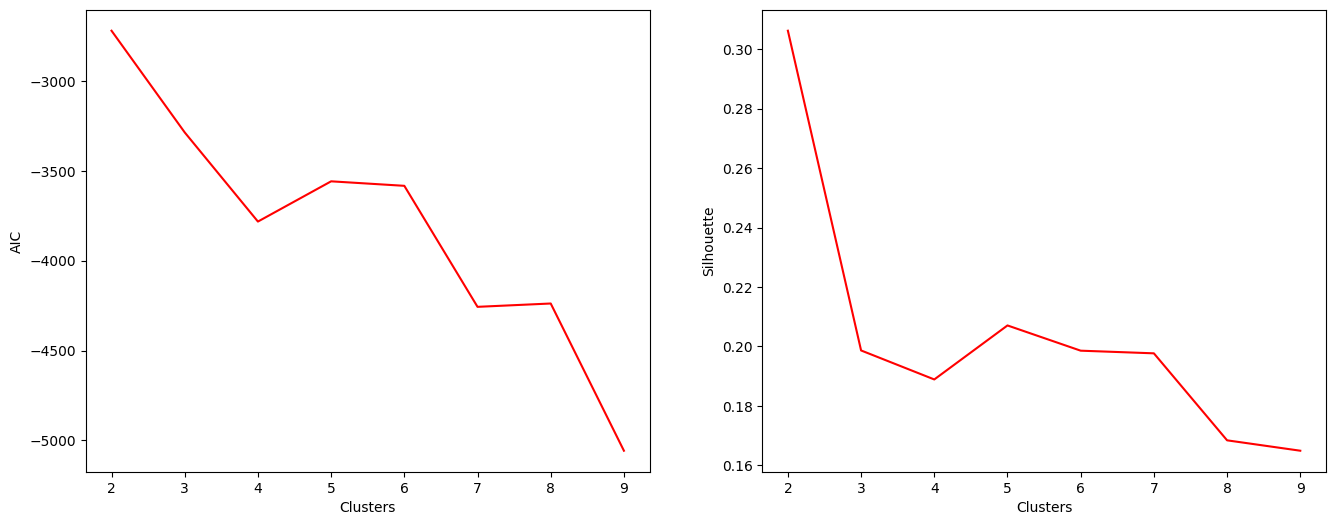

In [43]:
fig, axs = plt.subplots(1, 2, figsize = (16,6))
plt.subplot(1, 2, 1)
sns.lineplot(x = np.arange(2,10), y = aics, markers = True, color = 'red')
plt.xlabel('Clusters')
plt.ylabel('AIC')
plt.subplot(1, 2, 2)
sns.lineplot(x = np.arange(2,10), y = sils, markers = True, color = 'red')
plt.xlabel('Clusters')
plt.ylabel('Silhouette')
plt.show()

In [44]:
gmm = GaussianMixture(2, random_state = 42)
gmm.fit(data)
gmm_labels = gmm.predict(data)
prob_labels = pd.DataFrame(gmm.predict_proba(data), columns = ['cluster0', 'cluster1'])
prob_labels = prob_labels.set_index(country_index)
prob_labels = prob_labels.map(lambda x: round(x, 2))

df_gmm = df_good
df_gmm['hard_clusters'] = gmm_labels
df_gmm = df_gmm.set_index(country_index)
df_gmm = pd.merge(df_gmm, prob_labels, on = 'Country Code', how = 'left')

df_gmm

,clean_cooking,elec_total,elec_rural,elec_urban,health_exp_gdp,health_exp_pc,gdp_pc,gni_pc_atlas,internet_use,life_exp,...,infant_mort_m,basic_water,pop_density,pop_female,pop_male,rural_share,urban_share,hard_clusters,cluster0,cluster1
Country Code,,,,,,,,,,,,,,,,,,,,,
AFG,35.90,92.74,90.88,98.08,18.696,4.385667,6.047161,6.045480,17.212,63.292,...,57.18,74.484,4.126821,16.795913,16.815066,74.678,25.322,1,0.0,1.0
AGO,49.72,48.08,100.00,74.98,2.956,4.255128,7.845572,7.733523,38.996,63.600,...,45.52,65.704,3.356381,16.674596,16.652753,31.746,68.254,1,0.0,1.0
ALB,84.30,100.00,100.00,100.00,7.016,6.014435,8.888600,8.849816,77.172,78.500,...,8.98,95.022,4.520381,14.045076,14.023915,42.504,57.496,0,1.0,0.0
AND,100.00,100.00,100.00,100.00,7.982,8.110859,10.644150,10.731675,93.554,82.782,...,3.00,100.000,5.124599,10.557347,10.598705,11.328,88.672,0,1.0,0.0
ARE,100.00,100.00,100.00,100.00,5.038,7.684493,10.725315,10.730755,99.830,81.404,...,4.90,100.000,4.933111,15.068027,15.654173,14.646,85.354,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VUT,18.26,67.00,57.44,94.36,4.091,4.864047,8.083024,8.206819,43.196,70.780,...,15.56,86.924,3.261591,11.926637,11.948778,77.462,22.538,1,0.0,1.0
WSM,37.66,99.16,98.96,99.98,6.239,5.529245,8.361068,8.353670,54.196,71.070,...,14.94,97.254,4.354001,11.571111,11.585081,82.194,17.806,1,0.0,1.0
ZAF,88.62,87.70,91.34,88.00,8.684,6.313490,8.746300,8.758498,73.580,64.964,...,26.80,90.918,3.944357,17.268854,17.211005,36.528,63.472,1,0.0,1.0


<Axes: xlabel='Country Code', ylabel='cluster0'>

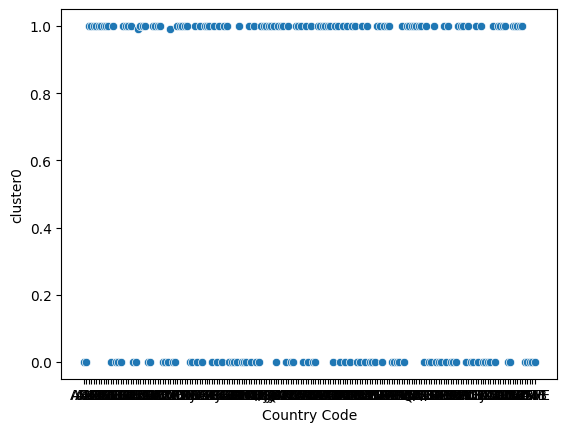

In [45]:
sns.scatterplot(df_gmm['cluster0'])

In [46]:
df_gmm = df_gmm.drop(columns = ['cluster0', 'cluster1'])

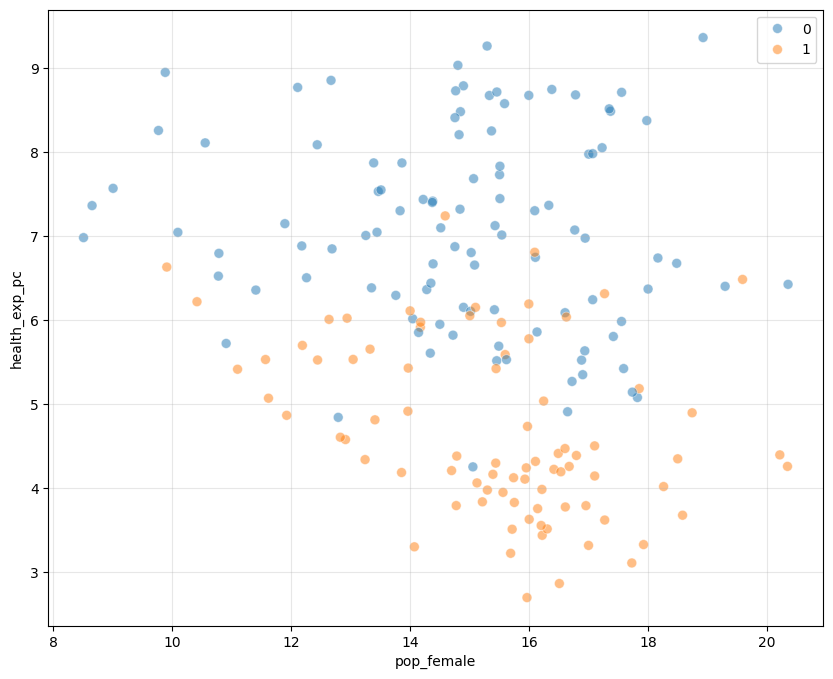

In [47]:
plt.figure(figsize = (10, 8))
sns.scatterplot(df_gmm, x = 'pop_female', y = 'health_exp_pc', hue = 'hard_clusters',
marker = 'o', palette = 'tab10', s = 50, alpha = 0.5)
plt.xlabel('pop_female')
plt.ylabel('health_exp_pc')
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

In [48]:
pca = PCA(n_components=2)
pca.fit(data)
pcas = pd.DataFrame(pca.transform(data), columns = ['pca1', 'pca2'])
pcas['cluster'] = gmm_labels
pcas = pcas.set_index(country_index)

In [49]:
pcas.groupby('cluster').count()

,pca1,pca2
cluster,,
0,102,102
1,82,82


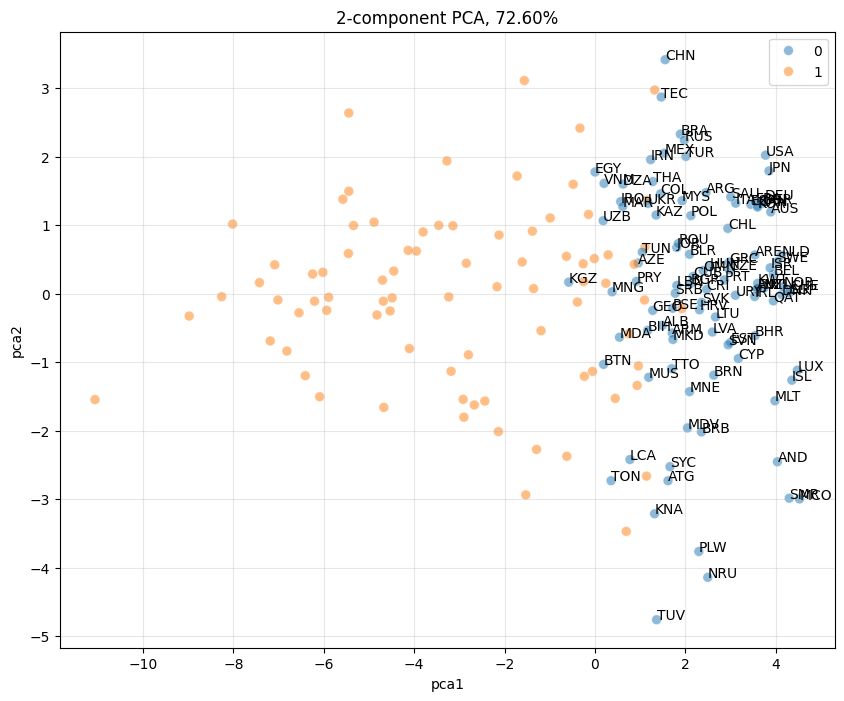

In [50]:
plt.figure(figsize = (10, 8))
sns.scatterplot(pcas, x = 'pca1', y = 'pca2', hue = 'cluster',
marker = 'o', palette = 'tab10', s = 50, alpha = 0.5)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title(f'{pca.n_components_}-component PCA, {sum(pca.explained_variance_ratio_)*100:.2f}%')
plt.grid(alpha = 0.3)
plt.legend()

for country in pcas[pcas['cluster'] == 0].index:
    
    plt.annotate(country, xy = [pcas.loc[country]['pca1'], pcas.loc[country]['pca2']])

plt.show()

A lot of countries are misplaced in developed region

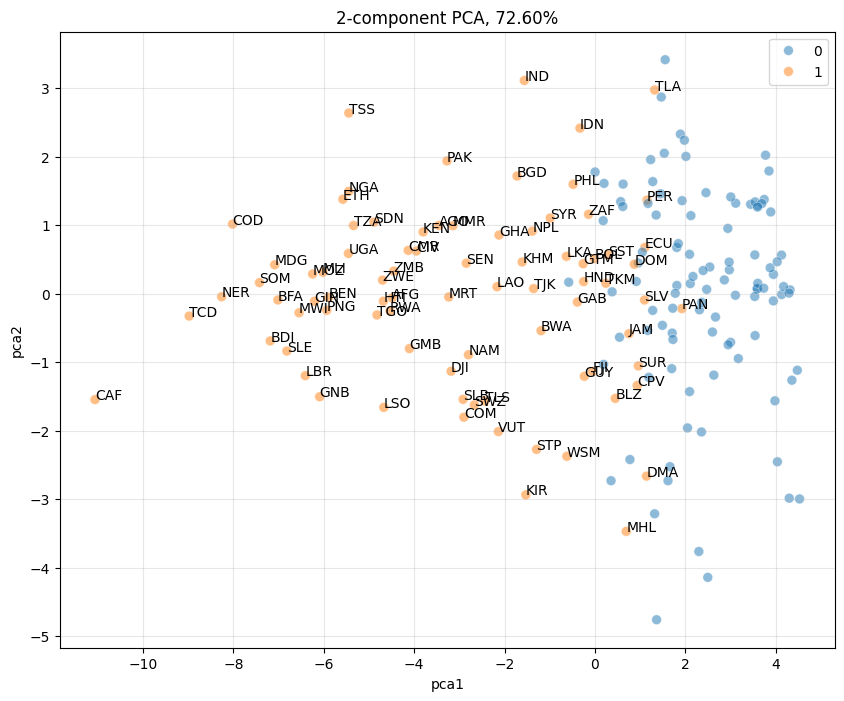

In [51]:
plt.figure(figsize = (10, 8))
sns.scatterplot(pcas, x = 'pca1', y = 'pca2', hue = 'cluster',
marker = 'o', palette = 'tab10', s = 50, alpha = 0.5)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title(f'{pca.n_components_}-component PCA, {sum(pca.explained_variance_ratio_)*100:.2f}%')
plt.grid(alpha = 0.3)
plt.legend()

for country in pcas[pcas['cluster'] == 1].index:
    
    plt.annotate(country, xy = [pcas.loc[country]['pca1'], pcas.loc[country]['pca2']])

plt.show()

In [52]:
developed = pcas[pcas['cluster'] == 0]
raw_data = df_good_prefillna.drop(columns = big_na_cols)
for country in developed.index:

    developed.loc[country, 'NAs'] = raw_data.loc[country].isna().sum().sum()

developed

C:\Users\4infi\AppData\Local\Temp\ipykernel_18508\3127494506.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  developed.loc[country, 'NAs'] = raw_data.loc[country].isna().sum().sum()


,pca1,pca2,cluster,NAs
Country Code,,,,
ALB,1.492655,-0.463499,0,2.0
AND,4.037100,-2.455682,0,0.0
ARE,3.537586,0.564672,0,2.0
ARG,2.456835,1.473499,0,7.0
ARM,1.710037,-0.576016,0,2.0
...,...,...,...,...
UKR,1.174565,1.316264,0,4.0
URY,3.108266,-0.024154,0,2.0
USA,3.775035,2.021057,0,2.0


In [53]:
developed.groupby('NAs').count()

df_good_prefillna.loc[developed.index].isna().sum()

clean_cooking        15
elec_total            0
elec_rural            0
elec_urban            0
health_exp_gdp       84
health_exp_pc        86
gdp_pc                3
gni_pc_atlas          9
internet_use         10
life_exp              0
maternal_risk         0
infant_mort_f         0
infant_mort_m         0
basic_water          10
basic_water_rural    80
basic_water_urban    55
pop_density           1
pop_female            0
pop_male              0
rural_share           0
enroll_primary       40
enroll_secondary     63
urban_share           0
dtype: int64

In [54]:
df_good_prefillna.fillna(df_good_prefillna.groupby("Country Code").median()).loc[developed.index].isna().sum()

clean_cooking        15
elec_total            0
elec_rural            0
elec_urban            0
health_exp_gdp        0
health_exp_pc         0
gdp_pc                0
gni_pc_atlas          5
internet_use          5
life_exp              0
maternal_risk         0
infant_mort_f         0
infant_mort_m         0
basic_water          10
basic_water_rural    80
basic_water_urban    55
pop_density           0
pop_female            0
pop_male              0
rural_share           0
enroll_primary       10
enroll_secondary     25
urban_share           0
dtype: int64

In [55]:
pca.components_

array([[ 2.62988880e-01,  2.59531979e-01,  2.53616040e-01,
         2.32515000e-01,  1.02540217e-01,  2.63624771e-01,
         2.64787689e-01,  2.64581238e-01,  2.77030355e-01,
         2.65269562e-01, -2.58446329e-01, -2.65543122e-01,
        -2.67498714e-01,  2.65803279e-01,  4.95921447e-02,
        -6.07444413e-02, -5.89528707e-02, -2.10611426e-01,
         2.10611426e-01],
       [ 5.88673086e-02,  2.43461532e-02,  1.90037042e-02,
         6.67453620e-02, -1.58348777e-01, -6.30492114e-02,
        -2.96624116e-02, -2.10194439e-02,  1.27083705e-02,
         7.94280767e-02, -4.43739462e-02, -3.67555680e-02,
        -3.72847867e-02, -2.07075495e-04, -1.19794557e-01,
         6.77660462e-01,  6.79517654e-01, -8.44256715e-02,
         8.44256715e-02]])

Health_exp_gdp and health_exp_pc are clearly influential, maybe data for a single year was missing

In [56]:
df_good_prefillna.isna().groupby('Year').mean()['health_exp_pc']

Year
2019    0.000000
2020    0.000000
2021    0.005435
2022    0.010870
2023    0.885870
Name: health_exp_pc, dtype: float64

It's true

Try pc-dimensional fit

In [57]:
pca_test = []

for k in np.arange(2,6):

    pca = PCA(n_components = k)
    pca.fit(data)
    pca_test.append({k: sum(pca.explained_variance_ratio_)})

pca_test = pd.DataFrame(pca_test)

In [58]:
pca = PCA(n_components = 4)
pca.fit(data)
data_pca4 = pca.transform(data)

gmm4 = GaussianMixture(n_components = 2, random_state = 42)
gmm4.fit(data_pca4)
gmm4_labels = gmm4.predict(data_pca4)
df_gmm4 = pd.DataFrame(gmm4.predict_proba(data_pca4), columns = ['cluster0', 'cluster1'])
df_gmm4 = df_gmm4.set_index(country_index)
df_gmm4 = df_gmm4.map(lambda x: round(x, 2))

df_gmm4['hard_clusters'] = gmm4_labels

df_gmm4

,cluster0,cluster1,hard_clusters
Country Code,,,
AFG,1.00,0.00,0
AGO,1.00,0.00,0
ALB,0.05,0.95,1
AND,0.01,0.99,1
ARE,0.00,1.00,1
...,...,...,...
VUT,1.00,0.00,0
WSM,0.04,0.96,1
ZAF,0.99,0.01,0


In [59]:
pd.merge(df_gmm4[df_gmm4['cluster0'] < 0.75], df_gmm4[df_gmm4['cluster0'] > 0.25], on = 'Country Code', how = 'inner')

,cluster0_x,cluster1_x,hard_clusters_x,cluster0_y,cluster1_y,hard_clusters_y
Country Code,,,,,,
ATG,0.39,0.61,1,0.39,0.61,1
CPV,0.67,0.33,0,0.67,0.33,0
EGY,0.39,0.61,1,0.39,0.61,1
IDN,0.33,0.67,1,0.33,0.67,1
PHL,0.73,0.27,0,0.73,0.27,0
SST,0.27,0.73,1,0.27,0.73,1


<Axes: xlabel='Country Code', ylabel='cluster0'>

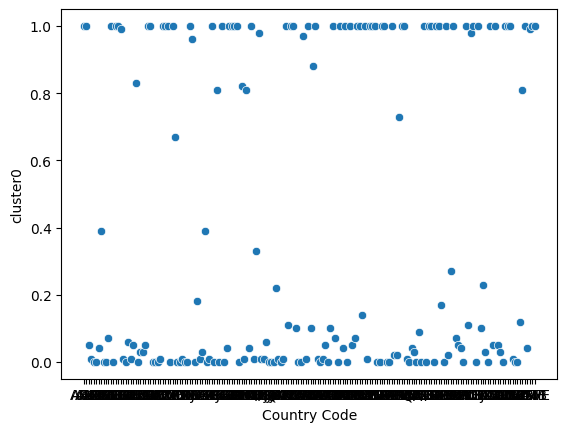

In [60]:
sns.scatterplot(df_gmm4['cluster0'])

In [61]:
df_gmm4.groupby('hard_clusters').count()

,cluster0,cluster1
hard_clusters,,
0,71,71
1,113,113


In [62]:
health_cols = ['health_exp_pc', 'health_exp_gdp']
df_good_no_health = df_good.drop(columns = health_cols)

data_no_health = scaler.fit_transform(df_good_no_health)

gmm_no_health = GaussianMixture(2, random_state = 42)
gmm_no_health.fit(data_no_health)
gmm_no_health_labels = gmm_no_health.predict(data_no_health)
prob_labels = pd.DataFrame(gmm_no_health.predict_proba(data_no_health), columns = ['cluster0', 'cluster1'])
prob_labels = prob_labels.set_index(country_index)
prob_labels = prob_labels.map(lambda x: round(x, 2))

df_gmm_no_health = df_good_no_health
df_gmm_no_health['hard_clusters'] = gmm_no_health_labels
df_gmm_no_health = df_gmm_no_health.set_index(country_index)
df_gmm_no_health = pd.merge(df_gmm_no_health, prob_labels, on = 'Country Code', how = 'left')


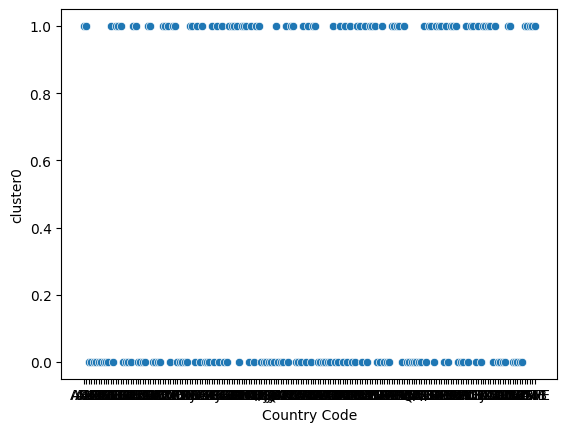

In [63]:
sns.scatterplot(df_gmm_no_health['cluster0'])
plt.show()

In [64]:
df_gmm_no_health = df_gmm_no_health.drop(columns = ['cluster0', 'cluster1'])

pca_no_health = PCA(n_components=2)
pca_no_health.fit(data_no_health)
pcas_no_health = pd.DataFrame(pca_no_health.transform(data_no_health), columns = ['pca1', 'pca2'])
pcas_no_health['cluster'] = gmm_no_health_labels
pcas_no_health = pcas_no_health.set_index(country_index)

In [65]:
pca_no_health.components_

array([[ 0.26768126,  0.26450113,  0.25862518,  0.23792883,  0.26444477,
         0.26395025,  0.28112093,  0.26902563, -0.26374902, -0.27066001,
        -0.27264912,  0.27015521,  0.05144848, -0.05788584, -0.0559357 ,
        -0.2108553 ,  0.2108553 , -0.23600012],
       [ 0.0496103 , -0.00851686, -0.01072207,  0.02441012, -0.02227178,
        -0.01031771,  0.0063919 ,  0.06784464, -0.01132507, -0.01628772,
        -0.01769231, -0.02288111, -0.13908925,  0.6867029 ,  0.68794207,
        -0.11266439,  0.11266439, -0.02686262]])

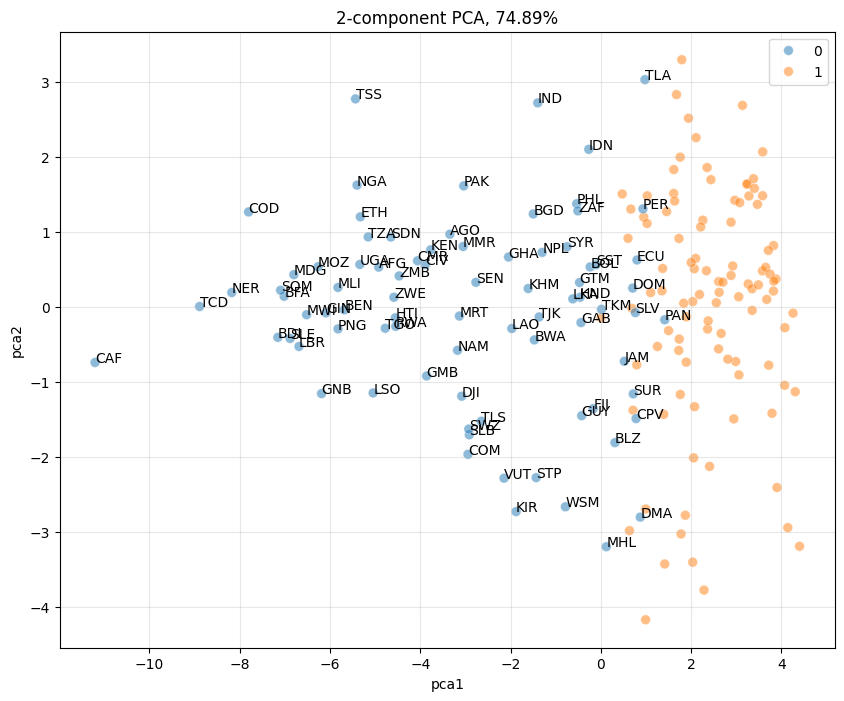

In [66]:
plt.figure(figsize = (10, 8))
sns.scatterplot(pcas_no_health, x = 'pca1', y = 'pca2', hue = 'cluster',
marker = 'o', palette = 'tab10', s = 50, alpha = 0.5)
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title(f'{pca_no_health.n_components_}-component PCA, {sum(pca_no_health.explained_variance_ratio_)*100:.2f}%')
plt.grid(alpha = 0.3)
plt.legend()

for country in pcas_no_health[pcas_no_health['cluster'] == 0].index:
    
    plt.annotate(country, xy = [pcas_no_health.loc[country]['pca1'], pcas_no_health.loc[country]['pca2']])

plt.show()

In [67]:
health_or_not = pd.merge(pcas['cluster'], pcas_no_health['cluster'], on = 'Country Code', how = 'left')

In [68]:
health_or_not['Change'] = abs(health_or_not['cluster_x'] - health_or_not['cluster_y'])

health_or_not['Change'].sum() 

np.int64(184)

No change at all from dropping health to clusters, but more explained variance

In [76]:
df_raw.loc[df_raw['Country Code'] == 'HKG']

,Country Name,Country Code,Series Name,Series Code,2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],...,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
3193,"Hong Kong SAR, China",HKG,"PM2.5 air pollution, population exposed to lev...",EN.ATM.PM25.MC.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3194,"Hong Kong SAR, China",HKG,"Population, female",SP.POP.TOTL.FE.IN,3572775,3612029,3657879,3693758,3715993,3758325,...,3960934,3995956,4033925,4072423,4109737,4102464,4068311,4032283,4138892,4134633
3195,"Hong Kong SAR, China",HKG,"Population, male",SP.POP.TOTL.MA.IN,3240425,3245071,3258421,3264042,3256807,3265875,...,3330366,3340644,3359275,3380177,3398163,3378536,3344789,3313817,3397208,3389467
3196,"Hong Kong SAR, China",HKG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,81.6090243902439,82.3848780487805,82.3668292682927,82.3404878048781,82.7751219512195,82.9575609756098,...,84.2526829268293,84.2114634146342,84.6956097560976,84.869756097561,85.1558536585366,85.4963414634146,85.5326829268293,83.6609756097561,85.2473170731707,..
3197,"Hong Kong SAR, China",HKG,Lifetime risk of maternal death (%),SH.MMR.RISK.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3198,"Hong Kong SAR, China",HKG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3199,"Hong Kong SAR, China",HKG,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3200,"Hong Kong SAR, China",HKG,"Hospital beds (per 1,000 people)",SH.MED.BEDS.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3201,"Hong Kong SAR, China",HKG,"Mortality rate, infant, female (per 1,000 live...",SP.DYN.IMRT.FE.IN,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3202,"Hong Kong SAR, China",HKG,"Mortality rate, infant, male (per 1,000 live b...",SP.DYN.IMRT.MA.IN,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
